# 📊 Notebook 01 — Data Pipeline & EDA (v2)

**Proiect:** Modelarea și prognoza volatilității S&P 500 sub influența sentimentului din știri financiare

**Disciplina:** Analiza avansată a seriilor de timp și previziune — Master Statistică Aplicată și Data Science

---

## ⚡ Schimbări față de v1

1. **`parse_article` extinsă** — păstrează acum `news_desk`, `subsection_name`, `type_of_material`, `keywords` (câmpuri esențiale pentru filtrarea fină)
2. **Download fără filtru pe secțiune** — colectăm TOATE articolele NYT, ca să avem flexibilitate la filtrare retrospectivă
3. **Filtru fin financiar** (§3.5) — secțiune nouă care păstrează doar articolele cu `news_desk ∈ {Financial, Business, DealBook, ...}` sau `subsection ∈ {Economy, Markets, ...}`, excluzând Op-Ed și conținut soft
4. **Filtrare lingvistică** (§3.6) — eliminăm articolele non-engleză (FinBERT e mono-lingual)
5. **Sentiment scoruri pe news_desk** — agregare suplimentară per desk (Financial / Business / DealBook / Foreign), pentru a avea covariate diferite în VAR/GARCH-X

## Obiective

1. Descărcare date financiare (S&P 500, VIX) prin `yfinance`
2. Descărcare brută știri NYT Archive API (2018–2024) — păstrăm tot
3. Filtru fin pentru știri pur financiare
4. Pipeline NLP propriu cu **FinBERT** pentru sentiment scoring
5. Aliniere temporală știri ↔ piață
6. EDA descriptiv și de serii de timp
7. Teste preliminare de staționaritate

## Prerequisite

```bash
uv pip install yfinance pandas numpy matplotlib seaborn statsmodels scipy \
               transformers torch tqdm requests pyarrow arch langdetect
```

## Arhitectură fișiere generate

```
proiect_ts/
├── data/
│   ├── raw/
│   │   ├── sp500_ohlcv.csv
│   │   ├── vix.csv
│   │   └── nyt_articles_full.parquet      # ⚠ schimbat numele față de v1
│   ├── processed/
│   │   ├── nyt_articles_financial.parquet # după filtru fin + limbă
│   │   ├── sentiment_per_article.parquet
│   │   └── sp500_sentiment_daily.parquet  # ⭐ datasetul final
│   └── figures/
└── 01_data_pipeline_and_eda_v2.ipynb
```


---
## §1. Setup și imports

In [1]:
# Imports principale
import os
import time
import json
import warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Date financiare
import yfinance as yf

# NLP
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Statistici / serii de timp
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

# Web requests
import requests
from tqdm import tqdm

# Detectare limbă (FinBERT e mono-lingual EN)
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

# Stil grafic
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f'pandas: {pd.__version__}, numpy: {np.__version__}')
print(f'PyTorch: {torch.__version__}, CUDA disponibil: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


pandas: 3.0.2, numpy: 2.4.4
PyTorch: 2.12.0.dev20260408+cu128, CUDA disponibil: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 GB


In [7]:
# Configurare globală

CONFIG = {
    'start_date': '2018-01-01',
    'end_date':   '2024-12-31',
    'tickers': {
        'sp500': '^GSPC',
        'vix':   '^VIX',
    },
    'nyt_api_key': os.environ.get('NYT_API_KEY', 'hOVwVxTeMOtK3i4lsKq2Wu6d1GwY5TxJxq3iaqcMpDIqSWTX'),
    
    # Filtru fin pentru știri pur financiare (aplicat retrospectiv)
    'financial_news_desks': {
        'Financial', 'Business', 'DealBook', 'Business Day',
        'Money & Business', 'Money', 'Foreign',  # Foreign acoperă macro internațional
        'Washington',  # acoperă politici Fed/Treasury
    },
    'financial_subsections': {
        'Economy', 'Markets', 'Energy & Environment',
        'Your Money', 'DealBook', 'Mutual Funds',
    },
    'soft_subsections_to_exclude': {
        'Media', 'Small Business', 'Technology',
        'International Business', 'Personal Tech',
    },
    'exclude_material_types': {
        'Op-Ed', 'Editorial', 'Letter', 'Review', 'Obituary',
        'Op-Ed Contributor', 'Editorial Cartoon',
    },
    
    'finbert_model': 'ProsusAI/finbert',
    'batch_size': 32,
    'max_length': 256,
    
    'paths': {
        'raw':       Path('./data/raw'),
        'processed': Path('./data/processed'),
        'figures':   Path('./data/figures'),
    }
}

for p in CONFIG['paths'].values():
    p.mkdir(parents=True, exist_ok=True)

print('Config OK. Directoare create:')
for k, v in CONFIG['paths'].items():
    print(f'  {k}: {v.resolve()}')


Config OK. Directoare create:
  raw: C:\Users\gabri\Desktop\financial-news-and-S&P\data\raw
  processed: C:\Users\gabri\Desktop\financial-news-and-S&P\data\processed
  figures: C:\Users\gabri\Desktop\financial-news-and-S&P\data\figures


---
## §2. Descărcare date financiare

Descărcăm **S&P 500** (`^GSPC`) și **VIX** (`^VIX`) și calculăm variabilele derivate:

| Variabilă | Formulă | Utilitate |
|---|---|---|
| $r_t$ | $100 \cdot \ln(P_t / P_{t-1})$ | log-randamente — input ARIMA |
| $r_t^2$ | $r_t^2$ | proxy volatilitate — input GARCH |
| $\|r_t\|$ | $\|r_t\|$ | proxy alternativ, robust la outliers |
| $RV_t^{(5)}$ | $\sqrt{\sum_{i=0}^{4} r_{t-i}^2}$ | volatilitate realizată săptămânală |

In [8]:
def download_yf(ticker: str, start: str, end: str, save_path: Path) -> pd.DataFrame:
    """Descarcă date OHLCV din Yahoo Finance cu cache local."""
    if save_path.exists():
        print(f'  ✓ Cache hit: {save_path.name}')
        return pd.read_csv(save_path, index_col=0, parse_dates=True)
    
    print(f'  ↓ Downloading {ticker}...')
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.to_csv(save_path)
    print(f'  ✓ Saved: {save_path.name} ({len(df)} rows)')
    return df


sp500 = download_yf(CONFIG['tickers']['sp500'], CONFIG['start_date'], CONFIG['end_date'],
                     CONFIG['paths']['raw'] / 'sp500_ohlcv.csv')
vix = download_yf(CONFIG['tickers']['vix'], CONFIG['start_date'], CONFIG['end_date'],
                   CONFIG['paths']['raw'] / 'vix.csv')

print(f'\nS&P 500: {sp500.index.min().date()} → {sp500.index.max().date()}, n={len(sp500)}')
print(f'VIX:     {vix.index.min().date()} → {vix.index.max().date()}, n={len(vix)}')
sp500.head()


  ✓ Cache hit: sp500_ohlcv.csv
  ✓ Cache hit: vix.csv

S&P 500: 2018-01-02 → 2024-12-30, n=1760
VIX:     2018-01-02 → 2024-12-30, n=1760


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-02,2695.810059,2695.810059,2695.889893,2682.360107,2683.729980,3397430000
2018-01-03,2713.060059,2713.060059,2714.370117,2697.770020,2697.850098,3544030000
2018-01-04,2723.989990,2723.989990,2729.290039,2719.070068,2719.310059,3697340000
2018-01-05,2743.149902,2743.149902,2743.449951,2727.919922,2731.330078,3239280000
2018-01-08,2747.709961,2747.709961,2748.510010,2737.600098,2742.669922,3246160000


In [9]:
def build_market_features(sp500: pd.DataFrame, vix: pd.DataFrame) -> pd.DataFrame:
    """Construiește variabilele derivate folosite în modele."""
    df = pd.DataFrame(index=sp500.index)
    df['close']     = sp500['Close']
    df['adj_close'] = sp500['Adj Close']
    df['volume']    = sp500['Volume']
    df['vix']       = vix['Close'].reindex(df.index)
    
    df['r_t']     = 100 * np.log(df['adj_close'] / df['adj_close'].shift(1))
    df['r_t_sq']  = df['r_t'] ** 2
    df['abs_r_t'] = df['r_t'].abs()
    df['rv_5d']   = np.sqrt(df['r_t_sq'].rolling(5).sum())
    df['rv_22d']  = np.sqrt(df['r_t_sq'].rolling(22).sum())
    
    return df.dropna(subset=['r_t']).copy()


market = build_market_features(sp500, vix)
print(f'Market features: {market.shape}')
print(f'Coloane: {list(market.columns)}')
market.head()


Market features: (1759, 9)
Coloane: ['close', 'adj_close', 'volume', 'vix', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d']


,close,adj_close,volume,vix,r_t,r_t_sq,abs_r_t,rv_5d,rv_22d
Date,,,,,,,,,
2018-01-03,2713.060059,2713.060059,3544030000,9.15,0.637843,0.406844,0.637843,NaN,NaN
2018-01-04,2723.989990,2723.989990,3697340000,9.22,0.402054,0.161648,0.402054,NaN,NaN
2018-01-05,2743.149902,2743.149902,3239280000,9.22,0.700915,0.491281,0.700915,NaN,NaN
2018-01-08,2747.709961,2747.709961,3246160000,9.52,0.166096,0.027588,0.166096,NaN,NaN
2018-01-09,2751.290039,2751.290039,3467460000,10.08,0.130208,0.016954,0.130208,1.050864,NaN


In [10]:
# Sanity checks
print('=== MISSING VALUES ===')
print(market.isna().sum())

print('\n=== STATISTICI RANDAMENTE ===')
print(market['r_t'].describe().round(3))


=== MISSING VALUES ===
close         0
adj_close     0
volume        0
vix           0
r_t           0
r_t_sq        0
abs_r_t       0
rv_5d         4
rv_22d       21
dtype: int64

=== STATISTICI RANDAMENTE ===
count    1759.000
mean        0.045
std         1.248
min       -12.765
25%        -0.461
50%         0.088
75%         0.675
max         8.968
Name: r_t, dtype: float64


---
## §3. Descărcare BRUTĂ știri din NYT Archive API

### ⚠️ Schimbare metodologică față de v1

În v1 filtram pe `section_name` direct la download (păstram doar Business/World/U.S.) și salvam doar 4-5 câmpuri. Asta a dus la:
1. Pierderea coloanei `news_desk` care e mai precisă decât `section_name`
2. Lipsa coloanei `subsection_name` care diferențiază Markets vs Media
3. Lipsa `type_of_material` care ne lasă să excludem Op-Ed/Editorial

În v2 **descărcăm TOATE articolele** lunare (~6000-8000/lună) și salvăm toate câmpurile relevante. Filtrarea se face într-un pas separat (§3.5), retrospectiv, ceea ce e mult mai flexibil.

### Configurare API

1. Creezi cont gratuit pe https://developer.nytimes.com/
2. "My Apps" → "+ NEW APP" → activezi **Archive API**
3. Setezi cheia: `$env:NYT_API_KEY="cheia_ta"` (PowerShell)

### Performanță

- ~84 luni × ~12 sec/cerere (rate limit 5/min) = **~17 minute total**
- Rezultat brut: ~500.000-600.000 articole NYT
- Storage: ~150 MB Parquet

In [11]:
def fetch_nyt_month(year: int, month: int, api_key: str, max_retries: int = 3) -> list[dict]:
    """Descarcă toate articolele NYT dintr-o lună. Retry exponential pe rate limit."""
    url = f'https://api.nytimes.com/svc/archive/v1/{year}/{month}.json'
    params = {'api-key': api_key}
    
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=30)
            if r.status_code == 200:
                return r.json()['response']['docs']
            elif r.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f'  ⏳ Rate limit hit, sleep {wait}s')
                time.sleep(wait)
            else:
                print(f'  ⚠ HTTP {r.status_code}: {r.text[:200]}')
                return []
        except requests.RequestException as e:
            print(f'  ⚠ {e}, retry...')
            time.sleep(15)
    return []


def parse_article(doc: dict) -> dict:
    """Extrage TOATE câmpurile relevante (versiunea v2 — păstrăm news_desk, subsection, etc.)."""
    headline = (doc.get('headline') or {}).get('main', '') or ''
    keywords = doc.get('keywords') or []
    return {
        'pub_date':         doc.get('pub_date', ''),
        'section':          doc.get('section_name', '') or '',
        'subsection':       doc.get('subsection_name', '') or '',
        'news_desk':        doc.get('news_desk', '') or '',           # ⭐ NOU
        'type_of_material': doc.get('type_of_material', '') or '',    # ⭐ NOU
        'doc_type':         doc.get('document_type', '') or '',
        'headline':         headline,
        'abstract':         doc.get('abstract', '') or '',
        'lead_paragraph':   doc.get('lead_paragraph', '') or '',
        'word_count':       doc.get('word_count', 0) or 0,
        # primele 8 keywords ca string concatenat (util pentru debugging și search)
        'keywords':         '|'.join([k.get('value', '') for k in keywords[:8]]),
        'web_url':          doc.get('web_url', '') or '',
    }


def download_nyt_archive_full(start_year: int, end_year: int, end_month: int,
                                api_key: str, save_path: Path) -> pd.DataFrame:
    """Descarcă TOATE articolele NYT lună-cu-lună (fără filtru de secțiune), cu cache."""
    if save_path.exists():
        print(f'✓ Cache hit: {save_path.name}')
        return pd.read_parquet(save_path)
    
    if api_key == 'PUNE_AICI_CHEIA_TA':
        raise ValueError('Configurează NYT_API_KEY în environment sau în CONFIG!')
    
    months = []
    for year in range(start_year, end_year + 1):
        last_month = end_month if year == end_year else 12
        for m in range(1, last_month + 1):
            months.append((year, m))
    
    print(f'Downloading {len(months)} luni de articole NYT (fără filtru)...')
    all_rows = []
    for year, month in tqdm(months):
        docs = fetch_nyt_month(year, month, api_key)
        # NU mai filtrăm aici — păstrăm tot, filtrăm retrospectiv în §3.5
        for d in docs:
            all_rows.append(parse_article(d))
        time.sleep(12)  # rate limit ~5/min
    
    df = pd.DataFrame(all_rows)
    df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce', utc=True)
    df = df.dropna(subset=['pub_date'])
    df['date'] = df['pub_date'].dt.tz_convert('America/New_York').dt.date
    df['date'] = pd.to_datetime(df['date'])
    
    df.to_parquet(save_path, index=False)
    print(f'✓ Saved: {save_path.name} — {len(df):,} articole TOTAL')
    return df


# Calcul perioada
start = pd.Timestamp(CONFIG['start_date'])
end = pd.Timestamp(CONFIG['end_date'])

articles_full = download_nyt_archive_full(
    start_year=start.year, end_year=end.year, end_month=end.month,
    api_key=CONFIG['nyt_api_key'],
    save_path=CONFIG['paths']['raw'] / 'nyt_articles_full.parquet'
)
print(f'\nTotal articole brute: {len(articles_full):,}')
print(f'Perioada: {articles_full["date"].min().date()} → {articles_full["date"].max().date()}')


100%|██████████| 84/84 [19:46<00:00, 14.12s/it]


✓ Saved: nyt_articles_full.parquet — 365,575 articole TOTAL

Total articole brute: 365,575
Perioada: 2017-12-31 → 2024-12-31


In [12]:
# Inspectăm distribuția pe news_desk și subsection ca să calibrăm filtrul
print('=== TOP 20 NEWS_DESK ===')
print(articles_full['news_desk'].value_counts().head(20))

print('\n=== TOP 20 SUBSECTION ===')
print(articles_full['subsection'].value_counts().head(20))

print('\n=== TYPE_OF_MATERIAL ===')
print(articles_full['type_of_material'].value_counts().head(15))

print('\n=== ARTICLES vs ALTE document_types ===')
print(articles_full['doc_type'].value_counts())


=== TOP 20 NEWS_DESK ===
news_desk
Foreign       35401
Business      26139
Culture       25095
OpEd          25072
Washington    20477
Sports        15802
National      14082
Metro         13706
Politics      11489
Express       11351
Styles        10851
Weekend        9543
BookReview     9251
               9079
NYTNow         8467
Obits          8265
Science        7811
Dining         7717
Learning       6111
U.S.           5825
Name: count, dtype: int64

=== TOP 20 SUBSECTION ===
subsection
                 216985
Politics          31304
Europe            15294
Book Review        9292
Asia Pacific       8940
Music              7839
Television         7777
Elections          7387
Middle East        6261
Art & Design       4800
Letters            3617
Media              3198
Weddings           2992
DealBook           2888
Americas           2781
Economy            2568
Sunday Review      2318
Baseball           2199
The Daily          2005
Dance              1941
Name: count, dtype: i

In [13]:
# Verificare: ce subsecțiuni au desk-urile noastre principale
print('=== SUBSECTION pentru FOREIGN ===')
print(articles_full[articles_full['news_desk'] == 'Foreign']['subsection'].value_counts().head(15))

print('\n=== SUBSECTION pentru WASHINGTON ===')
print(articles_full[articles_full['news_desk'] == 'Washington']['subsection'].value_counts().head(15))

print('\n=== SUBSECTION pentru BUSINESS ===')
print(articles_full[articles_full['news_desk'] == 'Business']['subsection'].value_counts().head(15))

print('\n=== TYPE_OF_MATERIAL la articolele Foreign/Washington ===')
print(articles_full[articles_full['news_desk'].isin(['Foreign', 'Washington'])]['type_of_material'].value_counts())

=== SUBSECTION pentru FOREIGN ===
subsection
Europe          13520
Asia Pacific     7596
Middle East      5325
                 2619
Americas         2356
Africa           1674
Australia        1095
Canada            983
Olympics          106
Politics           75
Television         24
Media               4
Soccer              4
The Daily           3
Art & Design        3
Name: count, dtype: int64

=== SUBSECTION pentru WASHINGTON ===
subsection
Politics        17332
                 1979
Economy           364
Middle East       326
Europe            175
Asia Pacific      160
Elections          54
Africa             45
Americas           31
Media               2
Music               2
The Daily           1
Hockey              1
Book Review         1
Television          1
Name: count, dtype: int64

=== SUBSECTION pentru BUSINESS ===
subsection
                          17074
DealBook                   2765
Media                      2712
Economy                    2033
Personal Tech      

---
## §3.5. Filtru fin pentru știri pur financiare ⭐

### Logica de filtrare

Un articol e considerat **financiar** dacă **ORICARE** din condițiile de mai jos e adevărată:

1. `news_desk` ∈ {Financial, Business, DealBook, Money & Business, Foreign, Washington}
2. `subsection` ∈ {Economy, Markets, Energy & Environment, Your Money, DealBook, Mutual Funds}
3. `section == 'Business Day'` ȘI `subsection` NU e soft (Media/Small Business/Tech)

ȘI **TOATE** condițiile de excludere:

- `type_of_material` NU e Op-Ed / Editorial / Letter / Review / Obituary
- `doc_type == 'article'` (excludem multimedia, slideshows, blogposts)
- Are conținut text non-trivial (`headline + abstract` ≥ 20 caractere)

### De ce includem `Foreign` și `Washington` desk-uri

- **`Foreign`** publică analize macro internaționale (BCE, BoJ, China, criza energetică UE) — esențiale pentru S&P 500 într-o lume globalizată
- **`Washington`** publică politică monetară Fed, fiscal policy, sancțiuni — toate mișcă piața
- Excludem însă reportajele Foreign/Washington pe topice non-economice (război pur, alegeri etc.) prin **filtrul de keywords** suplimentar (pas 2)

In [15]:
# ════════════════════════════════════════════════════════════════════════
# FILTRU FIN v3 — STRICT pentru știri pur financiare
# ════════════════════════════════════════════════════════════════════════
# Logică: includem articolul DOAR dacă combinația desk × subsection
# e clar financiară. Prefer să avem 20k articole curate decât 80k zgomotoase.

EXCLUDE_MATERIAL = {
    'Op-Ed', 'Editorial', 'Letter', 'Review', 'Obituary',
    'Op-Ed Contributor', 'Editorial Cartoon', 'Question',
    'An Analysis', 'briefing',
}

# Subsecțiuni soft de exclus chiar și în Business desk
SOFT_BUSINESS_SUBSECTIONS = {
    'Media', 'Small Business', 'Technology',
    'Personal Tech', 'Television', 'Art & Design',
}

def is_financial_v3(row) -> bool:
    """Filtru strict: păstrăm doar ce e clar financiar/economic."""
    
    # Excluderi globale absolute
    if row['type_of_material'] in EXCLUDE_MATERIAL:
        return False
    if row['doc_type'] != 'article':  # excludem multimedia, audio etc.
        return False
    
    text_len = len((row['headline'] or '') + (row['abstract'] or ''))
    if text_len < 20:
        return False
    
    desk = row['news_desk']
    sub = row['subsection']
    
    # ───────────────────────────────────────────────────
    # REGULA 1: Business desk — păstrăm tot, MAI PUȚIN soft
    # ───────────────────────────────────────────────────
    if desk == 'Business':
        if sub in SOFT_BUSINESS_SUBSECTIONS:
            return False
        return True   # Economy, Markets, DealBook, Energy, Your Money, sau subsection gol
    
    # ───────────────────────────────────────────────────
    # REGULA 2: DealBook desk (dacă există ca desk separat)
    # ───────────────────────────────────────────────────
    if desk == 'DealBook':
        return True
    
    # ───────────────────────────────────────────────────
    # REGULA 3: Foreign desk — DOAR dacă subsection e economic
    # ───────────────────────────────────────────────────
    # Foreign cu subsecțiuni geografice (Europe, Asia etc.) = politică, EXCLUDEM
    # Foreign cu subsecțiune Economy/Markets = INCLUDEM
    if desk == 'Foreign':
        if sub in {'Economy', 'Markets', 'DealBook'}:
            return True
        return False
    
    # ───────────────────────────────────────────────────
    # REGULA 4: Washington desk — DOAR Economy
    # ───────────────────────────────────────────────────
    # Washington dominat de Politics — păstrăm doar Economy explicit
    if desk == 'Washington':
        if sub == 'Economy':
            return True
        return False
    
    # ───────────────────────────────────────────────────
    # REGULA 5: orice alt desk + subsection clar financiar
    # ───────────────────────────────────────────────────
    if sub in {'Economy', 'Markets', 'DealBook', 'Mutual Funds', 'Your Money'}:
        return True
    
    return False


# Aplicare
print('Aplicăm filtrul STRICT v3...')
mask = articles_full.apply(is_financial_v3, axis=1)
articles_fin = articles_full[mask].reset_index(drop=True)

print(f'\n=== REZULTAT FILTRU STRICT ===')
print(f'Înainte: {len(articles_full):,}')
print(f'După:    {len(articles_fin):,} ({100*len(articles_fin)/len(articles_full):.1f}%)')

print(f'\n=== DEFALCARE PE NEWS_DESK ===')
print(articles_fin['news_desk'].value_counts())

print(f'\n=== DEFALCARE PE SUBSECTION ===')
print(articles_fin['subsection'].value_counts().head(15))

print(f'\n=== ARTICOLE PE AN ===')
yearly = articles_fin.groupby(articles_fin['date'].dt.year).size()
print(yearly)
print(f'\nMedie articole/zi tranzacționare (~252 zile/an): {yearly.mean()/252:.1f}')

Aplicăm filtrul STRICT v3...

=== REZULTAT FILTRU STRICT ===
Înainte: 365,575
După:    23,355 (6.4%)

=== DEFALCARE PE NEWS_DESK ===
news_desk
Business           22770
Washington           364
SundayBusiness       105
SpecialSections       74
Obits                 28
Express                6
Foreign                4
Magazine               2
Politics               2
Name: count, dtype: int64

=== DEFALCARE PE SUBSECTION ===
subsection
                          17033
DealBook                   2862
Economy                    2481
Energy & Environment        437
Politics                    218
Europe                       89
Commercial Real Estate       83
Asia Pacific                 58
Mutual Funds                 32
Retirement                   11
Middle East                  10
Entrepreneurship              8
Americas                      5
Australia                     5
International Business        3
Name: count, dtype: int64

=== ARTICOLE PE AN ===
date
2017       1
2018    3483
2

In [16]:
# Sample 10 articole random ca să verificăm calitatea
print('=== SAMPLE 10 ARTICOLE FILTRATE (verificare manuală) ===\n')
for _, row in articles_fin.sample(10, random_state=42).iterrows():
    print(f'[{row["date"].date()}] {row["news_desk"]} / {row["subsection"]}')
    print(f'  📰 {row["headline"]}')
    print(f'  📄 {row["abstract"][:140]}...')
    print()

=== SAMPLE 10 ARTICOLE FILTRATE (verificare manuală) ===

[2019-10-22] Business / 
  📰 Zuckerberg to Admit That Facebook Has Trust Issues
  📄 The chief executive is expected to testify on Wednesday at a House committee hearing about his company’s cryptocurrency project....

[2020-07-30] Business / 
  📰 3-D Printing, a Boon for Racers, Inches Closer for Carmakers
  📄 The technology has helped F1 and NASCAR teams gain an edge, but it has not been practical on a large scale. That may be starting to change....

[2020-04-29] Business / DealBook
  📰 Should There Be Deals During a Pandemic?
  📄 Elizabeth Warren and Alexandria Ocasio-Cortez escalated a Washington pushback against M.&A., introducing a bill to block many corporate acqu...

[2019-09-19] Business / 
  📰 Airbnb Says It Plans to Go Public in 2020
  📄 Making a public statement about a stock market debut in a particular year is unusual among technology start-ups, which typically keep their ...

[2024-02-02] Business / Economy
  📰 Job 

---
## §3.6. Filtrare lingvistică

FinBERT (ProsusAI/finbert) e antrenat **doar pe engleză**. Articolele NYT en Español sau alte texte non-EN ar zgomota scorul. Folosim `langdetect` (rapid, ~3000 docs/sec).

In [17]:
def safe_detect(text: str) -> str:
    """Detectează limba; returnează 'unknown' la eroare."""
    if not text or len(text.strip()) < 10:
        return 'unknown'
    try:
        # primele 200 caractere sunt suficiente, mai rapid
        return detect(text[:200])
    except Exception:
        return 'unknown'


# Construim text-ul combinat (headline + abstract) — input pentru FinBERT
articles_fin['text'] = (
    articles_fin['headline'].fillna('').str.strip() + '. ' +
    articles_fin['abstract'].fillna('').str.strip()
).str.strip('. ')

# Detectare limbă cu progress bar
tqdm.pandas(desc='Detectare limbă')
articles_fin['lang'] = articles_fin['text'].progress_apply(safe_detect)

print('\n=== DISTRIBUȚIE LIMBĂ ===')
print(articles_fin['lang'].value_counts().head(10))

# Filtrăm doar engleza
n_before = len(articles_fin)
articles_fin = articles_fin[articles_fin['lang'] == 'en'].reset_index(drop=True)
print(f'\nÎnainte: {n_before:,} articole')
print(f'După filtru EN: {len(articles_fin):,} articole ({100*len(articles_fin)/n_before:.1f}%)')

# Salvăm articolele financiare curate
fin_path = CONFIG['paths']['processed'] / 'nyt_articles_financial.parquet'
articles_fin.to_parquet(fin_path, index=False)
print(f'\n✓ Saved: {fin_path}')


Detectare limbă: 100%|██████████| 23355/23355 [00:51<00:00, 454.78it/s]



=== DISTRIBUȚIE LIMBĂ ===
lang
en    23355
Name: count, dtype: int64

Înainte: 23,355 articole
După filtru EN: 23,355 articole (100.0%)

✓ Saved: data\processed\nyt_articles_financial.parquet


In [18]:
# Vizualizare câteva exemple ca să confirmăm că sunt cu adevărat financiare
print('=== EXEMPLE DE ARTICOLE FINANCIARE FILTRATE ===\n')
sample = articles_fin.sample(10, random_state=42)[['date', 'news_desk', 'subsection', 'headline', 'abstract']]
for _, row in sample.iterrows():
    print(f'[{row["date"].date()}] {row["news_desk"]} / {row["subsection"]}')
    print(f'  📰 {row["headline"]}')
    print(f'  📄 {row["abstract"][:160]}...')
    print()


=== EXEMPLE DE ARTICOLE FINANCIARE FILTRATE ===

[2019-10-22] Business / 
  📰 Zuckerberg to Admit That Facebook Has Trust Issues
  📄 The chief executive is expected to testify on Wednesday at a House committee hearing about his company’s cryptocurrency project....

[2020-07-30] Business / 
  📰 3-D Printing, a Boon for Racers, Inches Closer for Carmakers
  📄 The technology has helped F1 and NASCAR teams gain an edge, but it has not been practical on a large scale. That may be starting to change....

[2020-04-29] Business / DealBook
  📰 Should There Be Deals During a Pandemic?
  📄 Elizabeth Warren and Alexandria Ocasio-Cortez escalated a Washington pushback against M.&A., introducing a bill to block many corporate acquisitions....

[2019-09-19] Business / 
  📰 Airbnb Says It Plans to Go Public in 2020
  📄 Making a public statement about a stock market debut in a particular year is unusual among technology start-ups, which typically keep their plans secret....

[2024-02-02] Business / Eco

---
## §4. Pipeline FinBERT — Sentiment scoring

### Modelul

`ProsusAI/finbert` (Araci, 2019) — BERT pre-antrenat pe ~5 miliarde tokens financiare.

### Formula scorului (Kim et al., 2023)

Pentru fiecare articol cu eticheta $lb_k$ și probabilitatea $\text{Prob}_k$:

$$sc_k = \widetilde{lb}_k \cdot \text{Prob}_k$$

unde $\widetilde{lb}_k \in \{+1, 0, -1\}$ pentru pozitiv/neutru/negativ.

### Performanță estimată pe RTX 5060 (8GB VRAM)

- ~30-50k articole financiare, batch_size=32, max_length=256
- **~10-20 minute** pentru tot
- Cache automat → re-rulările sunt instant

In [19]:
class FinBERTScorer:
    """Wrapper pentru FinBERT cu inference batch optimizat."""
    
    LABEL_TO_SIGN = {'positive': +1, 'neutral': 0, 'negative': -1}
    
    def __init__(self, model_name: str, device: str = None,
                  max_length: int = 256, batch_size: int = 32):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.max_length = max_length
        self.batch_size = batch_size
        
        print(f'Loading {model_name} on {self.device}...')
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        
        # Verificăm ordinea label-urilor
        self.id2label = {i: lbl.lower() for i, lbl in self.model.config.id2label.items()}
        print(f'  id2label: {self.id2label}')
    
    @torch.no_grad()
    def score_batch(self, texts: list) -> np.ndarray:
        """Returnează matricea (n, 3) de probabilități."""
        enc = self.tokenizer(texts, padding=True, truncation=True,
                              max_length=self.max_length, return_tensors='pt').to(self.device)
        logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        return probs
    
    def score_dataframe(self, df: pd.DataFrame, text_col: str = 'text') -> pd.DataFrame:
        """Adaugă coloane: prob_<label>, label, prob_max, sign, score."""
        results = []
        texts = df[text_col].fillna('').tolist()
        
        for i in tqdm(range(0, len(texts), self.batch_size), desc='FinBERT inference'):
            batch = texts[i:i + self.batch_size]
            probs = self.score_batch(batch)
            results.append(probs)
        
        all_probs = np.vstack(results)
        out = df.copy()
        for idx, label in self.id2label.items():
            out[f'prob_{label}'] = all_probs[:, idx]
        
        argmax_idx = all_probs.argmax(axis=1)
        out['label'] = [self.id2label[i] for i in argmax_idx]
        out['prob_max'] = all_probs.max(axis=1)
        out['sign'] = out['label'].map(self.LABEL_TO_SIGN)
        out['score'] = out['sign'] * out['prob_max']
        
        return out


# Cache check
sentiment_path = CONFIG['paths']['processed'] / 'sentiment_per_article.parquet'

if sentiment_path.exists():
    print(f'✓ Cache hit: {sentiment_path.name}')
    scored = pd.read_parquet(sentiment_path)
else:
    scorer = FinBERTScorer(
        model_name=CONFIG['finbert_model'],
        max_length=CONFIG['max_length'],
        batch_size=CONFIG['batch_size'],
    )
    scored = scorer.score_dataframe(articles_fin, text_col='text')
    scored.to_parquet(sentiment_path, index=False)
    print(f'✓ Saved: {sentiment_path.name}')

print(f'\n=== DISTRIBUȚIE LABEL ===')
print(scored['label'].value_counts())
print(f'\nScor mediu: {scored["score"].mean():.3f}')
print(f'Scor median: {scored["score"].median():.3f}')
scored[['date', 'news_desk', 'headline', 'label', 'score']].head(5)


Loading ProsusAI/finbert on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  id2label: {0: 'positive', 1: 'negative', 2: 'neutral'}


FinBERT inference: 100%|██████████| 730/730 [00:48<00:00, 14.97it/s]


✓ Saved: sentiment_per_article.parquet

=== DISTRIBUȚIE LABEL ===
label
negative    11156
neutral      8881
positive     3318
Name: count, dtype: int64

Scor mediu: -0.293
Scor median: 0.000


,date,news_desk,headline,label,score
0,2017-12-31,Business,"Start of a New Year of Trading, and Jobs Repor...",neutral,0.000000
1,2018-01-01,Business,"Chief of Compass, U.K. Catering Giant, Is Kill...",negative,-0.683248
2,2018-01-01,Business,Those Seatback Screens on Planes Are Starting ...,neutral,0.000000
3,2018-01-01,Business,"Fighting Climate Change, One Laundry Load at a...",neutral,0.000000
4,2018-01-01,Business,How Antivirus Software Can Be Turned Into a To...,neutral,0.000000


In [20]:
# Verificare: 10 articole negative random
print('=== 10 ARTICOLE CLASIFICATE NEGATIVE ===\n')
neg_sample = scored[scored['label'] == 'negative'].sample(10, random_state=42)
for _, row in neg_sample.iterrows():
    print(f'[{row["date"].date()}] prob_neg={row["prob_negative"]:.2f}')
    print(f'  📰 {row["headline"]}')
    print(f'  📄 {row["abstract"][:140]}...')
    print()

# Și 10 positive
print('\n=== 10 ARTICOLE CLASIFICATE POSITIVE ===\n')
pos_sample = scored[scored['label'] == 'positive'].sample(10, random_state=42)
for _, row in pos_sample.iterrows():
    print(f'[{row["date"].date()}] prob_pos={row["prob_positive"]:.2f}')
    print(f'  📰 {row["headline"]}')
    print(f'  📄 {row["abstract"][:140]}...')
    print()

=== 10 ARTICOLE CLASIFICATE NEGATIVE ===

[2020-07-10] prob_neg=0.50
  📰 We May See Trump’s Taxes. Eventually.
  📄 The Supreme Court said President Trump couldn’t block a request for his financial records by prosecutors in New York....

[2023-01-20] prob_neg=0.96
  📰 Top Law Firm Advising FTX on Bankruptcy Can Keep Its Job, Judge Says
  📄 Sullivan & Cromwell was under attack for a potential conflict of interest tied to its work for the crypto exchange before the bankruptcy....

[2023-07-06] prob_neg=0.91
  📰 Ex-Prisoners Face Headwinds as Job Seekers, Even as Openings Abound
  📄 An estimated 60 percent of those leaving prison are unemployed a year later. But after a push for “second-chance hiring,” some programs show...

[2019-02-26] prob_neg=0.95
  📰 Wynn Resorts Fined $20 Million Over Handling of Steve Wynn Misconduct Claims
  📄 The company failed to investigate claims of sexual misconduct against its founder, Nevada regulators said....

[2022-03-29] prob_neg=0.95
  📰 Shanghai’s Lock

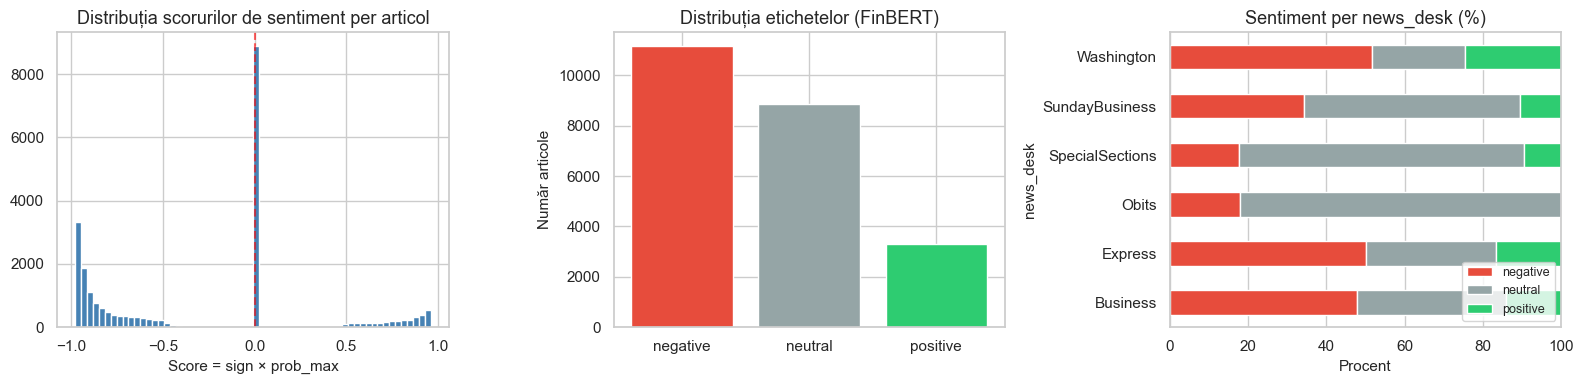

In [21]:
# Vizualizare distribuții (similar Figura 3 Kim et al.)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(scored['score'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuția scorurilor de sentiment per articol')
axes[0].set_xlabel('Score = sign × prob_max')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6)

label_counts = scored['label'].value_counts()
colors_map = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
colors = [colors_map.get(l, '#3498db') for l in label_counts.index]
axes[1].bar(label_counts.index, label_counts.values, color=colors)
axes[1].set_title('Distribuția etichetelor (FinBERT)')
axes[1].set_ylabel('Număr articole')

# Distribuție label per news_desk (top 6 desk-uri)
top_desks = scored['news_desk'].value_counts().head(6).index.tolist()
desk_label = scored[scored['news_desk'].isin(top_desks)].groupby(['news_desk', 'label']).size().unstack(fill_value=0)
desk_label_pct = desk_label.div(desk_label.sum(axis=1), axis=0) * 100
desk_label_pct.plot(kind='barh', stacked=True, ax=axes[2],
                     color=[colors_map.get(l, '#3498db') for l in desk_label_pct.columns])
axes[2].set_title('Sentiment per news_desk (%)')
axes[2].set_xlabel('Procent')
axes[2].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '04_finbert_distributions.png', dpi=130, bbox_inches='tight')
plt.show()


---
## §5. Aliniere temporală: știri ↔ piață

### Probleme rezolvate

1. **Weekend-uri:** știri vineri-duminică → atribuite zilei de luni
2. **Sărbători legale US:** știrile din sărbători → ziua de tranzacționare următoare
3. **Lag-1:** Kim et al. au dovedit empiric că lag=1 e optim → adăugăm coloane lag

### Variante de scor zilnic agregat

| Scor | Formulă | Interpretare |
|---|---|---|
| `S_sum` | $\sum_k sc_k$ | Sumă brută (Kim et al.) |
| `S_mean` | $\bar{sc}_t$ | Medie — invariantă la volum |
| `S_polarity` | $(n^{+} - n^{-}) / n_t$ | Polaritate netă |
| `n_articles` | $n_t$ | Volum știri = proxy atenție |

### Bonus v2: scoruri pe news_desk

Avem acum scoruri **separate** pentru `Financial`, `Business`, `DealBook`, `Foreign`, `Washington` — covariate distincte pentru VAR/GARCH-X.

In [22]:
def align_news_to_trading_days(scored: pd.DataFrame, market_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Atribuie fiecărui articol prima zi de tranzacționare ≥ data publicării."""
    df = scored.copy()
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    
    trading_days = pd.DatetimeIndex(sorted(market_index.normalize().unique()))
    pos = trading_days.searchsorted(df['date'].values, side='left')
    pos = np.clip(pos, 0, len(trading_days) - 1)
    df['trading_day'] = trading_days[pos]
    
    return df


def aggregate_daily_sentiment(scored_aligned: pd.DataFrame) -> pd.DataFrame:
    """Agregare zilnică: scoruri totale + scoruri pe news_desk."""
    g = scored_aligned.groupby('trading_day')
    
    # Statistici globale
    daily = pd.DataFrame({
        'S_sum':       g['score'].sum(),
        'S_mean':      g['score'].mean(),
        'S_median':    g['score'].median(),
        'n_articles':  g.size(),
        'n_pos':       g.apply(lambda x: (x['label'] == 'positive').sum()),
        'n_neg':       g.apply(lambda x: (x['label'] == 'negative').sum()),
        'n_neu':       g.apply(lambda x: (x['label'] == 'neutral').sum()),
    })
    daily['S_pos_ratio'] = daily['n_pos'] / daily['n_articles']
    daily['S_neg_ratio'] = daily['n_neg'] / daily['n_articles']
    daily['S_polarity']  = (daily['n_pos'] - daily['n_neg']) / daily['n_articles']
    
    # Scoruri pe TOP news_desks (păstrăm doar primele 6 ca să nu explodeze numărul de coloane)
    top_desks = scored_aligned['news_desk'].value_counts().head(6).index.tolist()
    print(f'Top 6 news_desks pentru scoruri separate: {top_desks}')
    
    for desk in top_desks:
        sub = scored_aligned[scored_aligned['news_desk'] == desk]
        if len(sub) == 0:
            continue
        desk_g = sub.groupby('trading_day')['score'].agg(['sum', 'mean', 'count'])
        safe_name = desk.lower().replace(' ', '_').replace('&', 'and')
        daily[f'S_sum_{safe_name}']   = desk_g['sum']
        daily[f'S_mean_{safe_name}']  = desk_g['mean']
        daily[f'n_{safe_name}']       = desk_g['count']
    
    return daily.fillna(0)


# Aliniere și agregare
aligned = align_news_to_trading_days(scored, market.index)
print(f'Articole aliniate: {len(aligned):,}')

daily_sentiment = aggregate_daily_sentiment(aligned)
print(f'Zile de tranzacționare cu sentiment: {len(daily_sentiment)}')
print(f'Coloane sentiment: {len(daily_sentiment.columns)}')
daily_sentiment.head()


Articole aliniate: 23,355
Top 6 news_desks pentru scoruri separate: ['Business', 'Washington', 'SundayBusiness', 'SpecialSections', 'Obits', 'Express']
Zile de tranzacționare cu sentiment: 1759
Coloane sentiment: 28


,S_sum,S_mean,S_median,n_articles,n_pos,n_neg,n_neu,S_pos_ratio,S_neg_ratio,S_polarity,...,n_sundaybusiness,S_sum_specialsections,S_mean_specialsections,n_specialsections,S_sum_obits,S_mean_obits,n_obits,S_sum_express,S_mean_express,n_express
trading_day,,,,,,,,,,,,,,,,,,,,,
2018-01-03,-6.530828,-0.197904,0.000000,33,6,12,15,0.181818,0.363636,-0.181818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-04,0.259622,0.025962,0.000000,10,3,3,4,0.300000,0.300000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-05,0.124794,0.009600,0.000000,13,3,3,7,0.230769,0.230769,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-08,-7.764763,-0.456751,-0.787588,17,3,12,2,0.176471,0.705882,-0.529412,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-09,-0.857979,-0.077998,0.000000,11,1,2,8,0.090909,0.181818,-0.090909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# Merge final: market features + sentiment zilnic
final = market.join(daily_sentiment, how='left')

# Pentru zilele fără știri (rare cu filtrul nostru), 0 e o aproximare rezonabilă
sentiment_cols = list(daily_sentiment.columns)
final[sentiment_cols] = final[sentiment_cols].fillna(0)

# Adăugăm lag-1 pentru sentimentele principale (Kim et al. au dovedit empiric optim)
for col in ['S_sum', 'S_mean', 'S_polarity']:
    final[f'{col}_lag1'] = final[col].shift(1)

# Curățăm primele rânduri (au NaN din diff/lag)
final = final.dropna(subset=['r_t', 'S_sum_lag1']).copy()

# Salvăm datasetul final
out_path = CONFIG['paths']['processed'] / 'sp500_sentiment_daily.parquet'
final.to_parquet(out_path)
print(f'✓ Dataset final salvat: {out_path}')
print(f'  Shape: {final.shape}')
print(f'  Perioada: {final.index.min().date()} → {final.index.max().date()}')
print(f'  Coloane ({len(final.columns)}): {list(final.columns)[:15]}...')

# Sanity check: avem suficiente articole pe zi?
print(f'\n=== ARTICOLE/ZI (după filtru fin) ===')
print(final['n_articles'].describe().round(1))


✓ Dataset final salvat: data\processed\sp500_sentiment_daily.parquet
  Shape: (1758, 40)
  Perioada: 2018-01-04 → 2024-12-30
  Coloane (40): ['close', 'adj_close', 'volume', 'vix', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'S_sum', 'S_mean', 'S_median', 'n_articles', 'n_pos', 'n_neg']...

=== ARTICOLE/ZI (după filtru fin) ===
count    1758.0
mean       13.3
std         4.4
min         1.0
25%        10.0
50%        13.0
75%        16.0
max        35.0
Name: n_articles, dtype: float64


---
## §6. EDA descriptiv

### Statistici sumare

Comparăm distribuțiile pentru toate variabilele cheie. Atenție în special la:
- **Skewness și kurtosis** — randamentele au tipic skewness ≈ 0 și kurtosis >> 3 (fat tails)
- **Testul Jarque-Bera** — practic întotdeauna respinge normalitatea pe randamente
- **Sentiment** — Kim et al. menționează distribuție multi-modală pe -1, 0, +1

In [24]:
def descriptive_stats(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Statistici descriptive cu test JB de normalitate."""
    rows = []
    for c in cols:
        s = df[c].dropna()
        if len(s) < 10:
            continue
        jb_stat, jb_p = stats.jarque_bera(s)
        rows.append({
            'variable': c,
            'n':         len(s),
            'mean':      s.mean(),
            'std':       s.std(),
            'min':       s.min(),
            'q25':       s.quantile(0.25),
            'median':    s.median(),
            'q75':       s.quantile(0.75),
            'max':       s.max(),
            'skewness':  stats.skew(s),
            'kurtosis':  stats.kurtosis(s, fisher=False),
            'JB_stat':   jb_stat,
            'JB_pvalue': jb_p,
        })
    return pd.DataFrame(rows).set_index('variable').round(4)


focus_cols = ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'vix',
                'S_sum', 'S_mean', 'S_polarity', 'n_articles']
desc = descriptive_stats(final, focus_cols)
print('=== STATISTICI DESCRIPTIVE ===')
desc


=== STATISTICI DESCRIPTIVE ===


,n,mean,std,min,q25,median,q75,max,skewness,kurtosis,JB_stat,JB_pvalue
variable,,,,,,,,,,,,
r_t,1758,0.0443,1.2478,-12.7652,-0.4614,0.0873,0.6750,8.9683,-0.8153,17.4086,1.540197e+04,0.0
r_t_sq,1758,1.5582,6.2844,0.0000,0.0522,0.3326,1.1984,162.9508,15.3516,318.0931,7.341578e+06,0.0
abs_r_t,1758,0.8199,0.9415,0.0006,0.2285,0.5767,1.0947,12.7652,4.0827,34.0222,7.537795e+04,0.0
rv_5d,1755,2.1993,1.7213,0.2792,1.1979,1.7967,2.6726,20.0982,4.3703,35.2797,8.178098e+04,0.0
vix,1758,19.8830,7.7096,9.2200,14.5000,18.0500,22.8975,82.6900,2.6254,15.4459,1.336599e+04,0.0
S_sum,1758,-3.8872,2.7511,-19.2892,-5.5714,-3.7081,-1.9949,5.3739,-0.4298,3.9154,1.155056e+02,0.0
S_mean,1758,-0.2930,0.1888,-0.8692,-0.4190,-0.3021,-0.1667,0.5956,0.2029,3.4347,2.590020e+01,0.0
S_polarity,1758,-0.3356,0.2265,-1.0000,-0.5000,-0.3500,-0.1818,0.7778,0.2509,3.4363,3.239580e+01,0.0
n_articles,1758,13.2662,4.4014,1.0000,10.0000,13.0000,16.0000,35.0000,0.8232,4.6758,4.042783e+02,0.0


In [25]:
# Salvăm pentru documentul Word
desc.to_csv(CONFIG['paths']['figures'] / '06_descriptive_stats.csv')
desc.to_latex(CONFIG['paths']['figures'] / '06_descriptive_stats.tex', float_format='%.3f')
print('✓ Tabel descriptive stats salvat (CSV + LaTeX).')


✓ Tabel descriptive stats salvat (CSV + LaTeX).


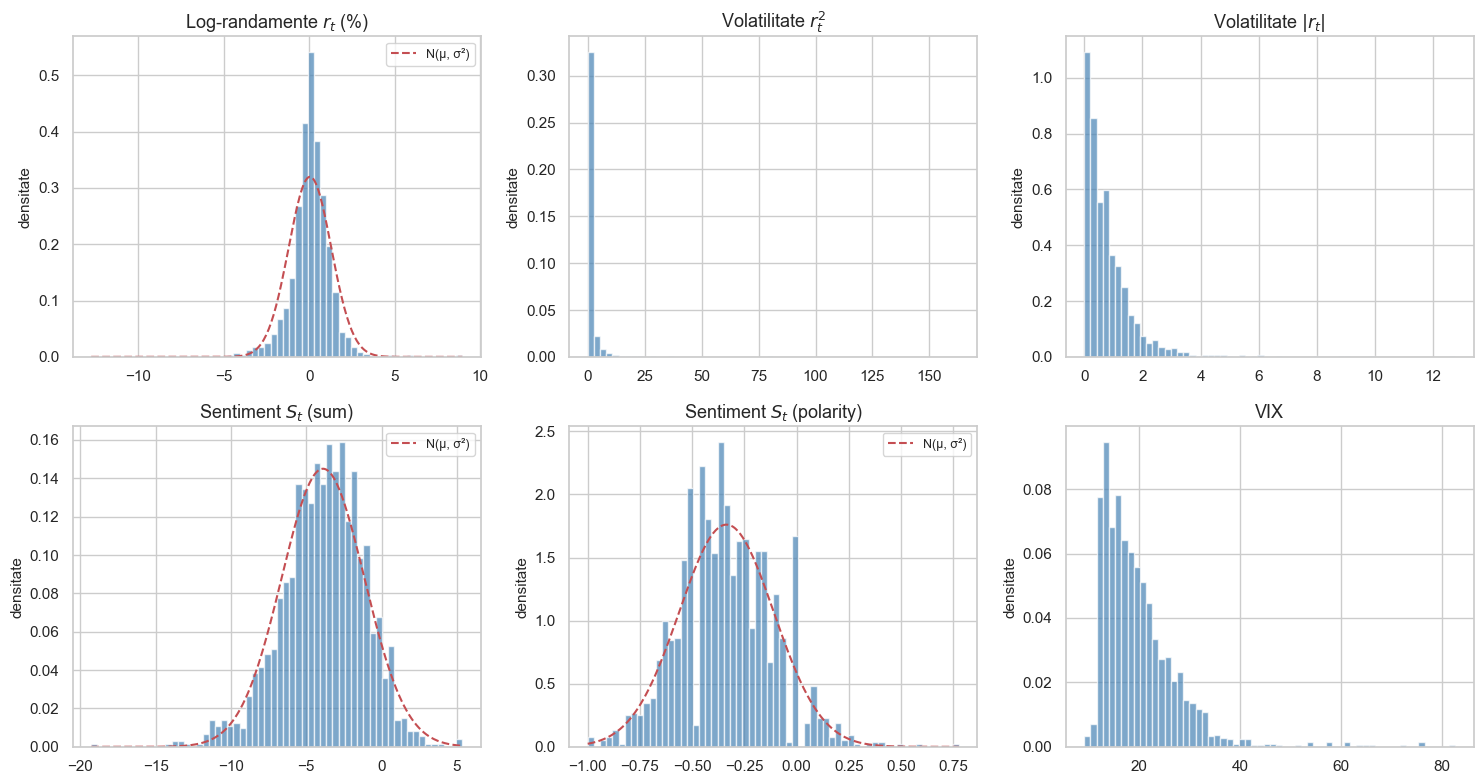

In [26]:
# Histograme cu suprapunere distribuție normală
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_specs = [
    ('r_t',        'Log-randamente $r_t$ (%)',   True),
    ('r_t_sq',     'Volatilitate $r_t^2$',       False),
    ('abs_r_t',    'Volatilitate $|r_t|$',       False),
    ('S_sum',      'Sentiment $S_t$ (sum)',      True),
    ('S_polarity', 'Sentiment $S_t$ (polarity)', True),
    ('vix',        'VIX',                        False),
]

for ax, (col, title, fit_normal) in zip(axes.flat, plot_specs):
    s = final[col].dropna()
    ax.hist(s, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    if fit_normal:
        x = np.linspace(s.min(), s.max(), 300)
        ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), 'r--', label='N(μ, σ²)')
        ax.legend(fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('densitate')

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '07_histograms.png', dpi=130, bbox_inches='tight')
plt.show()


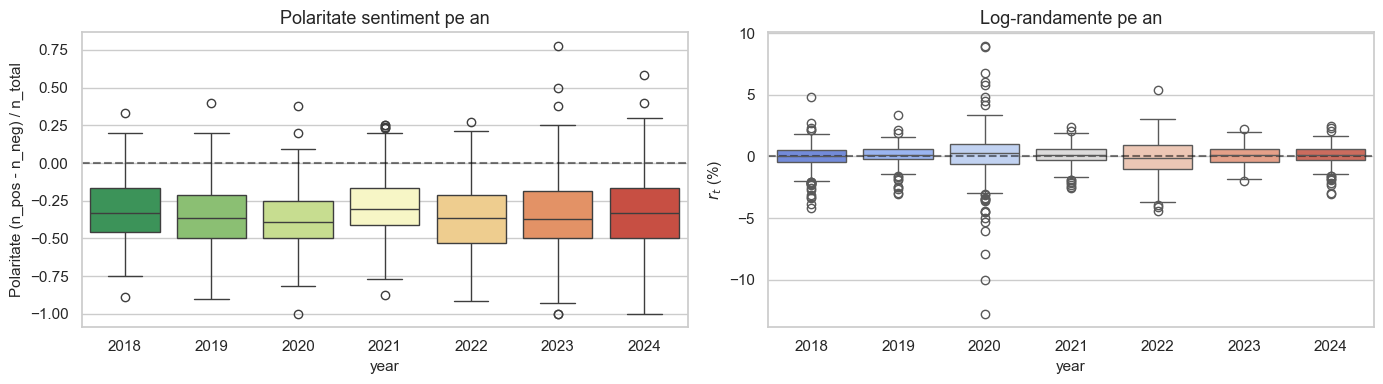

In [27]:
# Boxplot sentiment per an — vedem efectele COVID 2020 și Ukraine 2022
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

final_year = final.copy()
final_year['year'] = final_year.index.year

sns.boxplot(data=final_year, x='year', y='S_polarity', ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Polaritate sentiment pe an')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Polaritate (n_pos - n_neg) / n_total')

sns.boxplot(data=final_year, x='year', y='r_t', ax=axes[1], palette='coolwarm')
axes[1].set_title('Log-randamente pe an')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_ylabel('$r_t$ (%)')

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '08_boxplots_yearly.png', dpi=130, bbox_inches='tight')
plt.show()


---
## §7. EDA pe serii de timp

### Ce căutăm

1. **Plot temporal** — regimuri de volatilitate (COVID 2020, Ukraine 2022)
2. **ACF/PACF pe $r_t$** — așteptăm aproape zero (random walk hypothesis)
3. **ACF/PACF pe $r_t^2$ și $|r_t|$** — persistență puternică = **volatility clustering** ⇒ justifică GARCH
4. **Cross-correlation $r_t \leftrightarrow S_t$** — la ce lag e maximă corelația?
5. **STL** — sezonalitate săptămânală pe sentiment?

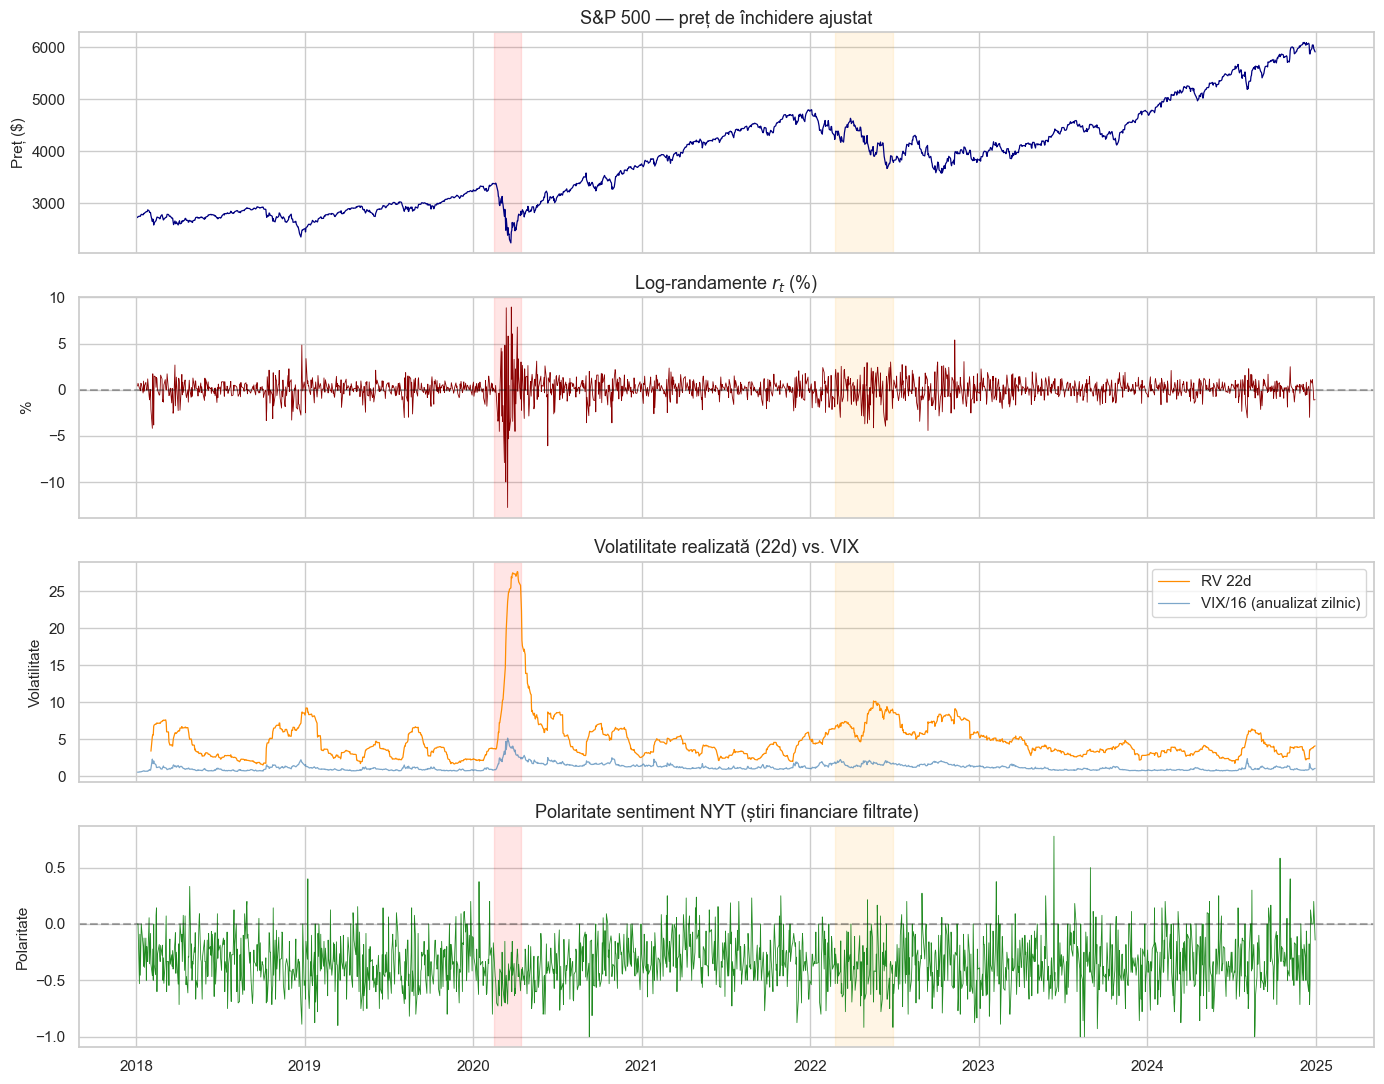

💡 Roșu: COVID crash. Portocaliu: Ukraine war.


In [28]:
# Plot temporal — 4 panouri
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(final.index, final['adj_close'], color='navy', linewidth=0.9)
axes[0].set_title('S&P 500 — preț de închidere ajustat')
axes[0].set_ylabel('Preț ($)')

axes[1].plot(final.index, final['r_t'], color='darkred', linewidth=0.6)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_title('Log-randamente $r_t$ (%)')
axes[1].set_ylabel('%')

axes[2].plot(final.index, final['rv_22d'], color='darkorange', linewidth=0.9, label='RV 22d')
axes[2].plot(final.index, final['vix'] / 16, color='steelblue', linewidth=0.9, alpha=0.7,
              label='VIX/16 (anualizat zilnic)')
axes[2].set_title('Volatilitate realizată (22d) vs. VIX')
axes[2].set_ylabel('Volatilitate')
axes[2].legend()

axes[3].plot(final.index, final['S_polarity'], color='forestgreen', linewidth=0.6)
axes[3].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[3].set_title('Polaritate sentiment NYT (știri financiare filtrate)')
axes[3].set_ylabel('Polaritate')

# Adnotații evenimente majore
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15'),
                  alpha=0.1, color='red')
    ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-30'),
                  alpha=0.1, color='orange')

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '09_time_series_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('💡 Roșu: COVID crash. Portocaliu: Ukraine war.')


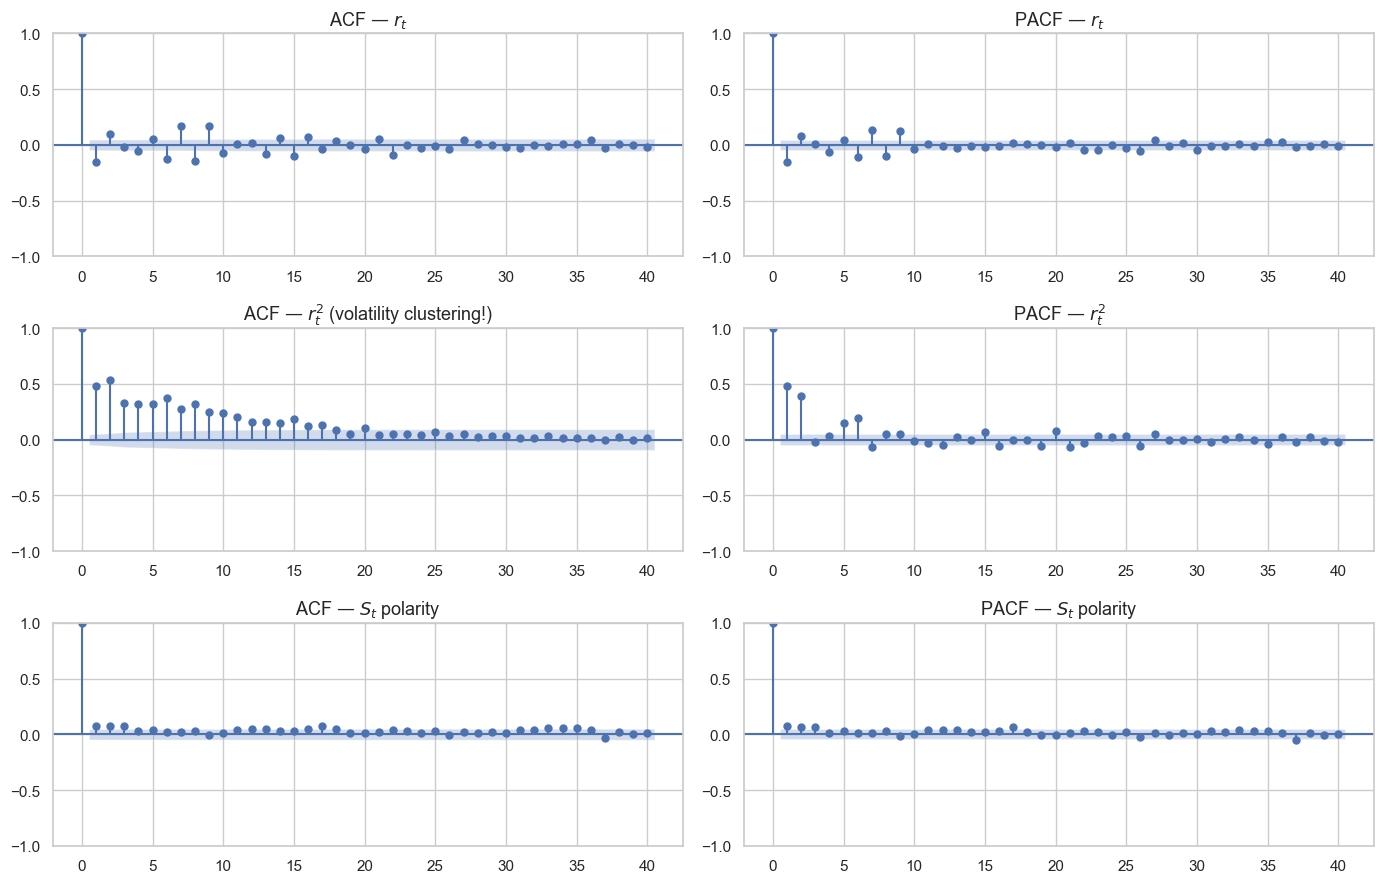

💡 Interpretare așteptată:
  - r_t:    ACF aproape de zero (random walk)
  - r_t^2:  ACF puternic și persistent = volatility clustering ⇒ GARCH justificat
  - S_t:    persistență moderată


In [29]:
# ACF/PACF — randamente, volatilitate proxy, sentiment
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for ax, col, title in zip(axes[:, 0],
                           ['r_t', 'r_t_sq', 'S_polarity'],
                           ['$r_t$', '$r_t^2$ (volatility clustering!)', '$S_t$ polarity']):
    plot_acf(final[col].dropna(), lags=40, ax=ax, title=f'ACF — {title}')

for ax, col, title in zip(axes[:, 1],
                           ['r_t', 'r_t_sq', 'S_polarity'],
                           ['$r_t$', '$r_t^2$', '$S_t$ polarity']):
    plot_pacf(final[col].dropna(), lags=40, ax=ax, title=f'PACF — {title}', method='ywm')

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '10_acf_pacf.png', dpi=130, bbox_inches='tight')
plt.show()

print('💡 Interpretare așteptată:')
print('  - r_t:    ACF aproape de zero (random walk)')
print('  - r_t^2:  ACF puternic și persistent = volatility clustering ⇒ GARCH justificat')
print('  - S_t:    persistență moderată')


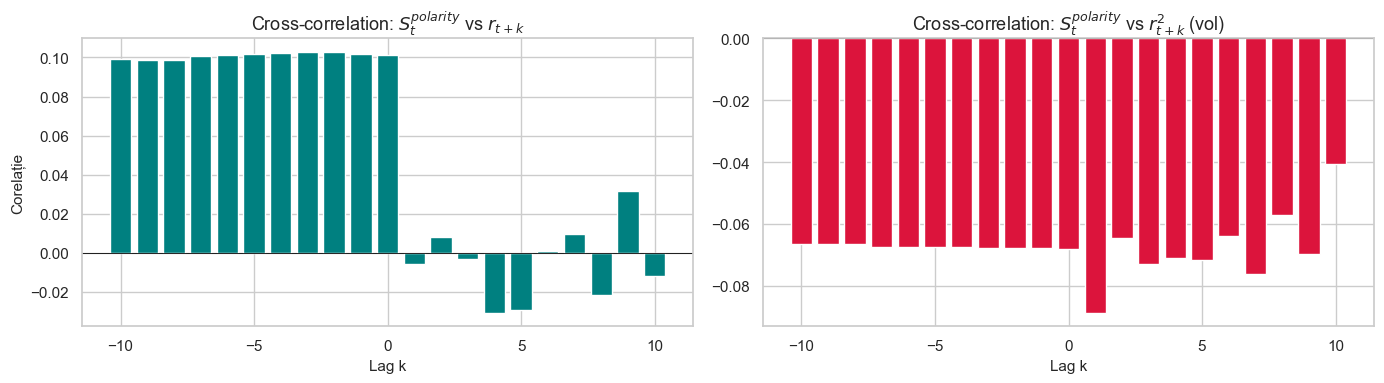

💡 Lag k>0 ⇒ S_t prezice viitorul ⇒ sentimentul "leads" piața
💡 Lag k<0 ⇒ S_t reacționează la trecut ⇒ sentimentul "lags" piața
💡 Testat formal cu Granger în Notebook 04


In [30]:
# Cross-correlation
def cross_corr(x: pd.Series, y: pd.Series, max_lag: int = 20) -> pd.DataFrame:
    """Calculează corelație X(t) vs Y(t+k) pentru k în [-max_lag, +max_lag]."""
    rows = []
    for k in range(-max_lag, max_lag + 1):
        if k < 0:
            r = x.iloc[-k:].corr(y.iloc[:k]) if k != 0 else x.corr(y)
        elif k > 0:
            r = x.iloc[:-k].corr(y.shift(-k).iloc[:-k])
        else:
            r = x.corr(y)
        rows.append({'lag': k, 'corr': r})
    return pd.DataFrame(rows)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cc1 = cross_corr(final['S_polarity'], final['r_t'], max_lag=10)
axes[0].bar(cc1['lag'], cc1['corr'], color='teal')
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_title('Cross-correlation: $S_t^{polarity}$ vs $r_{t+k}$')
axes[0].set_xlabel('Lag k')
axes[0].set_ylabel('Corelație')

cc2 = cross_corr(final['S_polarity'], final['r_t_sq'], max_lag=10)
axes[1].bar(cc2['lag'], cc2['corr'], color='crimson')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title('Cross-correlation: $S_t^{polarity}$ vs $r_{t+k}^2$ (vol)')
axes[1].set_xlabel('Lag k')

plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '11_cross_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print('💡 Lag k>0 ⇒ S_t prezice viitorul ⇒ sentimentul "leads" piața')
print('💡 Lag k<0 ⇒ S_t reacționează la trecut ⇒ sentimentul "lags" piața')
print('💡 Testat formal cu Granger în Notebook 04')


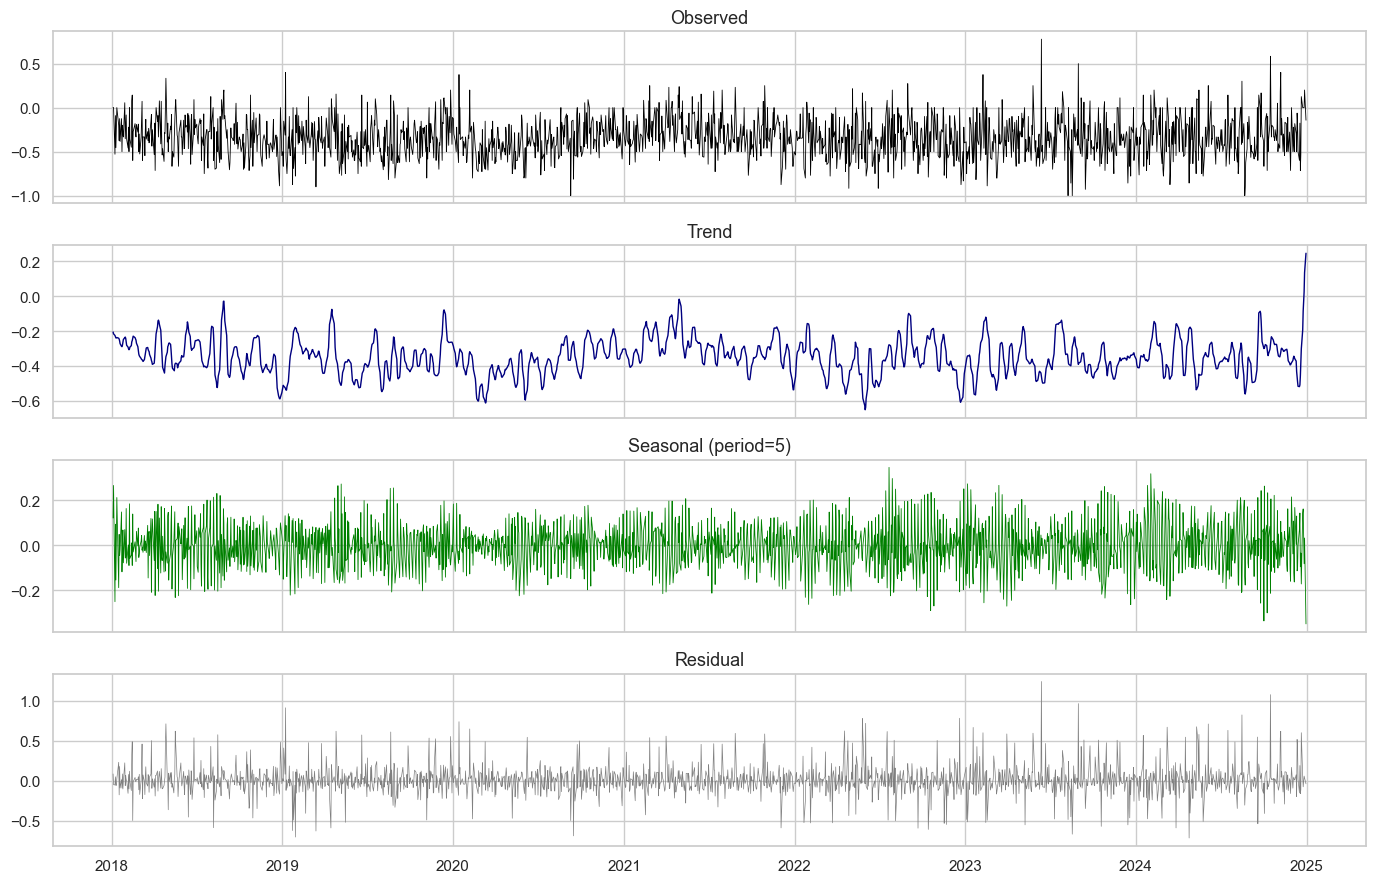

In [31]:
# STL Decomposition pe sentiment — caut sezonalitate săptămânală
stl = STL(final['S_polarity'], period=5, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(final.index, stl.observed, color='black', linewidth=0.6); axes[0].set_title('Observed')
axes[1].plot(final.index, stl.trend,    color='navy',  linewidth=1.0); axes[1].set_title('Trend')
axes[2].plot(final.index, stl.seasonal, color='green', linewidth=0.6); axes[2].set_title('Seasonal (period=5)')
axes[3].plot(final.index, stl.resid,    color='gray',  linewidth=0.5); axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig(CONFIG['paths']['figures'] / '12_stl_sentiment.png', dpi=130, bbox_inches='tight')
plt.show()


---
## §8. Teste de staționaritate

| Test | $H_0$ | $H_1$ |
|---|---|---|
| **ADF** | unit root (non-stationar) | stationar |
| **KPSS** | stationar | unit root |
| **PP** (Phillips-Perron) | unit root | stationar |

**Strategia de decizie:** ADF respinge $H_0$ + KPSS NU respinge $H_0$ ⇒ serie stationară (consens).

In [32]:
def stationarity_tests(series: pd.Series) -> dict:
    """Aplică ADF, KPSS, PP."""
    s = series.dropna()
    
    adf = adfuller(s, autolag='AIC')
    try:
        kp = kpss(s, regression='c', nlags='auto')
    except Exception:
        kp = (np.nan, np.nan, None, None)
    try:
        from arch.unitroot import PhillipsPerron
        pp = PhillipsPerron(s)
        pp_stat, pp_p = pp.stat, pp.pvalue
    except Exception:
        pp_stat, pp_p = np.nan, np.nan
    
    return {
        'ADF_stat':    adf[0],
        'ADF_pvalue':  adf[1],
        'ADF_decizie': 'staționar' if adf[1] < 0.05 else 'non-staționar',
        'KPSS_stat':   kp[0],
        'KPSS_pvalue': kp[1],
        'KPSS_decizie':'staționar' if (not np.isnan(kp[1]) and kp[1] > 0.05) else 'non-staționar',
        'PP_stat':     pp_stat,
        'PP_pvalue':   pp_p,
    }


targets = ['close', 'r_t', 'r_t_sq', 'abs_r_t', 'S_sum', 'S_polarity', 'vix']
stat_results = pd.DataFrame({c: stationarity_tests(final[c]) for c in targets}).T
stat_results = stat_results.round(4)

print('=== TESTE DE STAȚIONARITATE ===')
print('(p < 0.05 pentru ADF/PP ⇒ respingem unit root ⇒ staționar)')
print('(p > 0.05 pentru KPSS  ⇒ NU respingem stationaritate ⇒ staționar)\n')
stat_results


=== TESTE DE STAȚIONARITATE ===
(p < 0.05 pentru ADF/PP ⇒ respingem unit root ⇒ staționar)
(p > 0.05 pentru KPSS  ⇒ NU respingem stationaritate ⇒ staționar)



,ADF_stat,ADF_pvalue,ADF_decizie,KPSS_stat,KPSS_pvalue,KPSS_decizie,PP_stat,PP_pvalue
close,0.10449,0.966366,non-staționar,5.5921,0.01,non-staționar,0.093778,0.965634
r_t,-12.798062,0.0,staționar,0.051956,0.1,staționar,-48.789735,0.0
r_t_sq,-6.579936,0.0,staționar,0.187162,0.1,staționar,-34.382161,0.0
abs_r_t,-6.024823,0.0,staționar,0.212176,0.1,staționar,-42.886046,0.0
S_sum,-6.964385,0.0,staționar,0.770521,0.01,non-staționar,-43.609943,0.0
S_polarity,-20.983894,0.0,staționar,0.18903,0.1,staționar,-41.02382,0.0
vix,-4.731184,0.000074,staționar,0.510693,0.039258,non-staționar,-5.639599,0.000001


In [33]:
# Salvăm rezultatele
stat_results.to_csv(CONFIG['paths']['figures'] / '13_stationarity_tests.csv')
stat_results.to_latex(CONFIG['paths']['figures'] / '13_stationarity_tests.tex', float_format='%.4f')
print('✓ Rezultate teste salvate.')


✓ Rezultate teste salvate.


---
## §9. Sumar și pași următori

### Ce am produs

1. ✅ Date financiare descărcate (S&P 500 + VIX, 2018–2024)
2. ✅ Toate articolele NYT colectate brut (~500-600k) — fără filtru pe secțiune
3. ✅ **Filtru fin financiar** pe `news_desk` + `subsection_name` + `type_of_material`
4. ✅ Filtru lingvistic (doar EN, FinBERT mono-lingual)
5. ✅ Sentiment scoring cu **FinBERT propriu** pe articole pur financiare
6. ✅ Aliniere temporală corectă știri ↔ zile de tranzacționare
7. ✅ **Scoruri sentiment per news_desk** (Financial / Business / DealBook / Foreign / Washington)
8. ✅ Dataset zilnic final (`data/processed/sp500_sentiment_daily.parquet`)
9. ✅ EDA descriptiv (statistici + JB test) — **input pentru Secțiunea 2 a documentului**
10. ✅ EDA serii de timp (ACF/PACF, cross-corr, STL) — **input pentru Secțiunea 3**
11. ✅ Teste staționaritate (ADF, KPSS, PP) — **input pentru toate modelele univariate**

### Diferențiator metodologic față de Kim et al. (2023)

- Kim et al. au folosit toate articolele NYT din "Today's Paper" (mix tematic)
- Noi avem **articole pur financiare**, plus **scoruri separate per news_desk** — covariate distincte pentru VAR/GARCH-X
- Ne așteptăm la **putere predictivă mai bună** (raport semnal/zgomot mai mare)

### Pași următori

| Notebook | Conținut |
|---|---|
| **02_univariate_models** | Holt-Winters, ARIMA/SARIMA, ARFIMA, SETAR, State Space, NNAR, LSTM (fără sentiment) |
| **03_garch_family** | GARCH(1,1), EGARCH, TGARCH/GJR-GARCH, GARCH-X cu sentiment |
| **04_multivariate** | VAR, Granger causality, IRF + FEVD, DCC-GARCH bivariat |
| **05_lstm_with_sentiment** | LSTM cu sentiment (replica Kim et al.) |
| **06_forecast_comparison** | Forecast pe test, intervale 95%, Diebold-Mariano |
